# Introduction

Stock price prediction is an obvious application for data analysis and modelling. Having an accurate idea as to the price of a given stock at any point informs the buyer as to whether or not a purchase of that stock at the time is advisable. Furthermore, modelling might well allow for predictions in future trends of the price of the stock, allowing one to make much more informed decisions regarding their investment portfolio. The most popular methods of modelling stock prices tend to involve deep learning models such as LSTM (long short-term memory) and machine learning. This notebook will attempt to build a model based on a "hybrid" approach that can then be used to predict the closing stock price of a given company; Apple Inc. (stock symbol AAPL) has been used as an example for the notebook only.

# Modelling Approach

## ARIMA

The approach to modelling stock prices will combine several methods and techniques from time series analysis, statistical modelling and machine learning. The first model used is the ARIMA (Autoregressive Integrated Moving Average) model, which is applied to the log returns of the stock price data. The autoregression (AR) component uses past values to predict future values. The differencing (I) component makes the data stationary (i.e. constant mean and variance) by subtracting the previous observation. The moving average (MA) component models the relationship between an observation and a residual error from a moving average model applied to lagged observations. In this case, it is used to model the log returns of the stock in question and get the residuals, which serve as an input to the GARCH model.<sup>1</sup>

## GARCH

The purpose GARCH (Generalized Autoregressive Conditional Heteroskedasticity) is to model the volatility, or variability, in stock returns over time. In this case, the GARCH model is fitted to the residuals of the ARIMA model to estimate volatility for the next 365 days. The volatility estimate produced by the GARCH model is then used in a machine learning model (CatBoost).<sup>1</sup>

## CatBoost

CatBoost is an open-source machine learning algorithm. It is a gradient boosting library that is designed for efficiency, scalability and speed. It is particularly powerful for problems involving categorical features, as it automatically handles categorical data without the need for pre-processing, such as one-hot encoding. CatBoost is optimized for both CPU and GPU usage, which makes it particularly fast, even on large datasets. It also uses techniques to reduce over-fitting, such as ordered boosting and regularization. In this instance, CatBoost is used as the final model for making predictions of stock prices, based on the features derived from ARIMA residuals and GARCH volatility.<sup>1</sup>

[*********************100%***********************]  1 of 1 completed


Best number of boosting rounds: 642


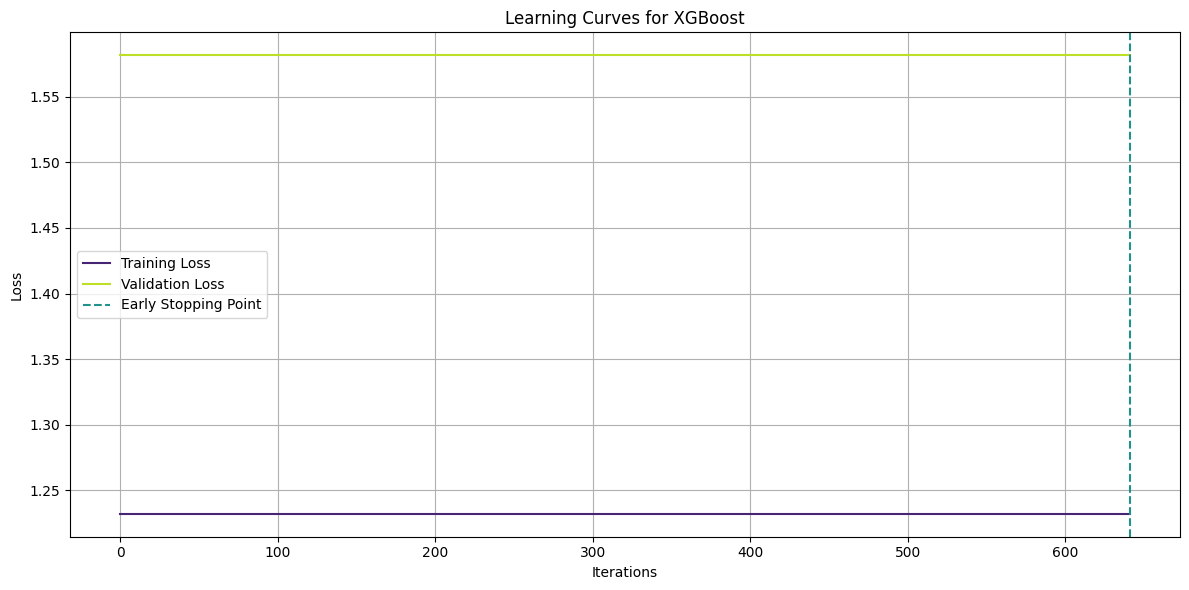

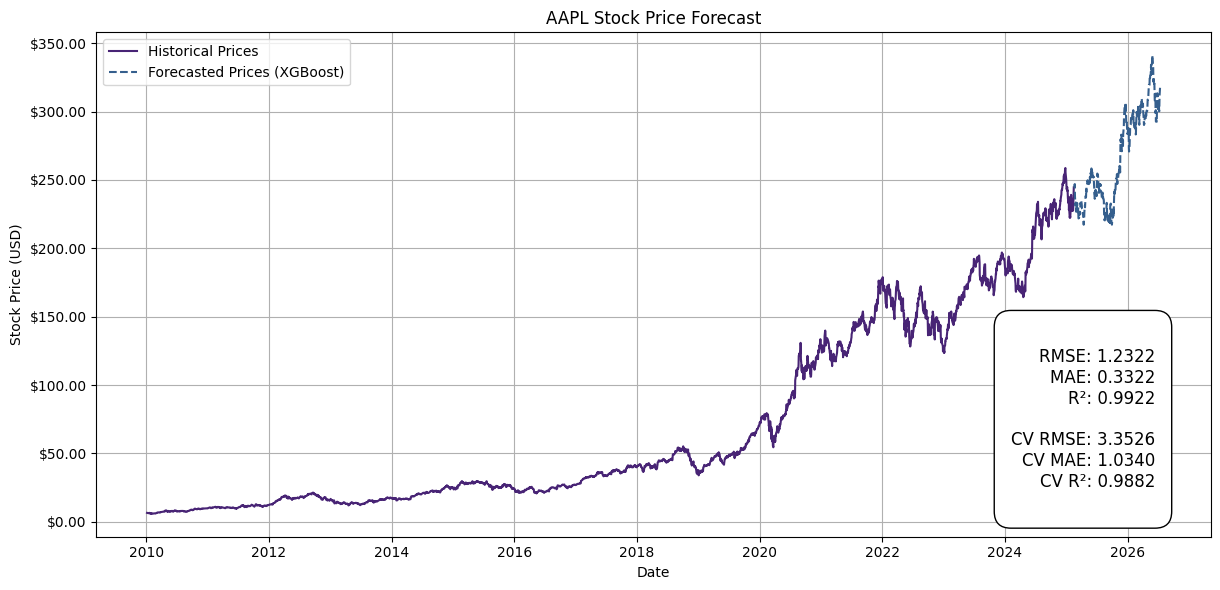

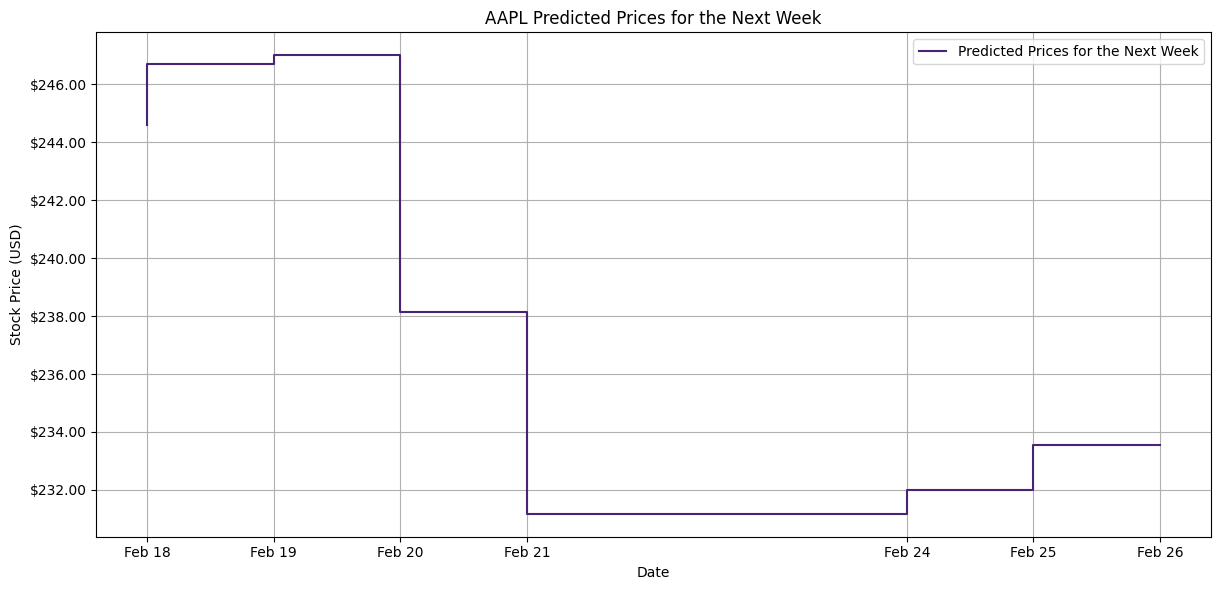

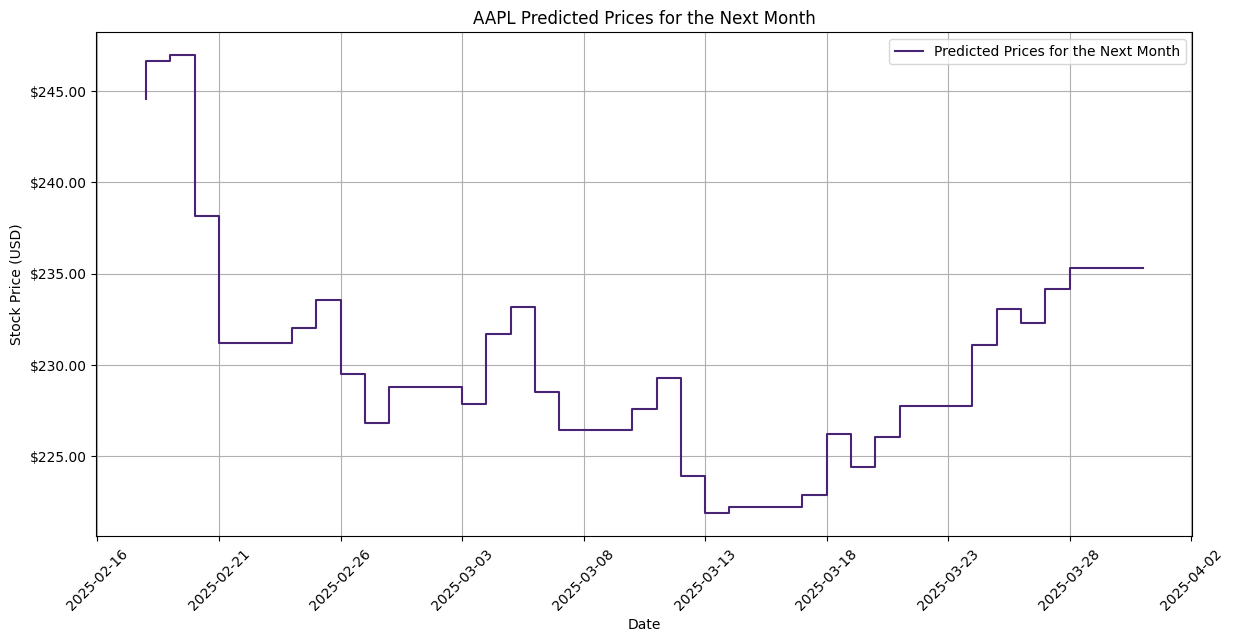

In [24]:
import datetime
import warnings
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.utils import io
from arch import arch_model
from matplotlib.ticker import FuncFormatter
from statsmodels.tsa.arima.model import ARIMA
import xgboost as xgb
import yfinance as yf
from pandas.tseries.offsets import BDay
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
import matplotlib.ticker as ticker

# Suppress warnings and console output.
warnings.filterwarnings("ignore")

# Download stock data.
stock_symbol = 'AAPL'
data = yf.download(stock_symbol, start='2010-01-01', end=datetime.date.today().strftime('%Y-%m-%d'))
data['Log_Ret'] = np.log(data['Close'] / data['Close'].shift(1))
data = data.dropna()

# Fit ARIMA model to the log returns.
log_returns = data['Log_Ret']
arima_model = ARIMA(log_returns, order=(5, 0, 0))
arima_result = arima_model.fit()

# ARIMA Residuals.
arima_residuals = arima_result.resid

# Fit GARCH model to the residuals of the ARIMA model.
garch_model = arch_model(arima_residuals, vol='Garch', p=1, q=1)
garch_result = garch_model.fit(disp="off")

# Forecast GARCH volatility for the next 365 days.
garch_forecast = garch_result.forecast(horizon=365)
garch_volatility = np.sqrt(garch_forecast.variance.iloc[-1]).values

# Prepare features.
features = pd.DataFrame({
    'ARIMA_Residuals': arima_residuals[-365:],  # Last 365 residuals.
    'GARCH_Volatility': garch_volatility
})

target = log_returns[-365:] * 1000  # Scale target.
features = features[np.isfinite(target)]
target = target[np.isfinite(target)]

# XGBoost - Hyperparameter Optimization with GridSearchCV.
# Split data into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, shuffle=False)

# Convert the data to DMatrix format for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define parameters for xgboost.cv.
param = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',  # Monitor RMSE for early stopping
    'learning_rate': 0.05,  # Learning rate
    'max_depth': 6,  # Max depth of trees
    'subsample': 0.8,  # Subsample ratio
    'colsample_bytree': 0.8,  # Column sampling for trees
    'seed': 42
}

# Perform cross-validation with early stopping.
cv_results = xgb.cv(
    params=param,
    dtrain=dtrain,
    num_boost_round=1000,  # Set a large number for boosting rounds
    early_stopping_rounds=50,  # Stop if no improvement in 50 rounds
    nfold=3,  # 3-fold cross-validation
    metrics="rmse",  # Monitor RMSE
    as_pandas=True,
    seed=42
)

# Get the best number of boosting rounds based on cross-validation results.
best_num_boost_round = cv_results['test-rmse-mean'].idxmin()
print(f"Best number of boosting rounds: {best_num_boost_round}")

# Train the final model using the best number of boosting rounds.
final_model = xgb.train(
    params=param,
    dtrain=dtrain,
    num_boost_round=best_num_boost_round
)

# ---- Learning Curves ----
train_losses = []
val_losses = []

# Track the training and validation losses for early stopping.
for epoch in range(best_num_boost_round):
    # Track the training loss.
    train_pred = final_model.predict(dtrain)
    val_pred = final_model.predict(dtest)
    
    train_loss = np.sqrt(mean_squared_error(y_train, train_pred))
    val_loss = np.sqrt(mean_squared_error(y_test, val_pred))
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)

# Plot the learning curves for the XGBoost model.
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Training Loss', color=plt.cm.viridis(0.1))
plt.plot(val_losses, label='Validation Loss', color=plt.cm.viridis(0.9))

# Add vertical dashed line for early stopping point.
early_stop_epoch = len(train_losses) - 1  # Epoch where early stopping occurred.
plt.axvline(x=early_stop_epoch, color=plt.cm.viridis(0.5), linestyle='--', label='Early Stopping Point')

# Add labels and title.
plt.title('Learning Curves for XGBoost')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Display the plot.
plt.tight_layout()
plt.show()

# ---- Performance Metrics ----
train_pred = final_model.predict(dtrain)
val_pred = final_model.predict(dtest)

# Calculate performance metrics for training and test sets
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, val_pred))
train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, val_pred)
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, val_pred)

# ---- Cross-validation metrics calculation ----
# Calculate cross-validation RMSE by directly evaluating the model's performance across the folds
cv_rmse_list = []
for i in range(cv_results.shape[0]):
    fold_rmse = cv_results.loc[i, 'test-rmse-mean']
    cv_rmse_list.append(fold_rmse)

cv_rmse = np.mean(cv_rmse_list)  # Calculate mean RMSE across all folds

# Cross-validation MAE and R² using final model predictions
cv_mae = np.mean(np.abs(final_model.predict(dtest) - y_test))
cv_r2 = r2_score(y_test, final_model.predict(dtest))

# Performance metrics text
metrics_text = f"""
RMSE: {train_rmse:.4f}
MAE: {train_mae:.4f}
R²: {train_r2:.4f}

CV RMSE: {cv_rmse:.4f}
CV MAE: {cv_mae:.4f}
CV R²: {cv_r2:.4f}
"""

# ---- Prediction and Forecasting ----

# Generate forecasted stock prices for the next 365 days using XGBoost.
forecast_dates = pd.date_range(start=datetime.date.today() + pd.Timedelta(days=1), periods=365, freq=BDay())

# Convert features to DMatrix for prediction
features_dmatrix = xgb.DMatrix(features)

# Get predicted future returns
future_returns = final_model.predict(features_dmatrix)  # Predictions based on the current data.
simulated_prices = np.zeros(365)
simulated_prices[0] = data['Close'].iloc[-1]

# Simulate prices for the forecast period.
for i in range(1, len(forecast_dates)):
    simulated_prices[i] = simulated_prices[i - 1] * np.exp(future_returns[i - 1] / 1000)

forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecasted_Price': simulated_prices[:len(forecast_dates)]})

# Plot the historical prices and forecasted prices (dashed).
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Historical Prices', color=plt.cm.viridis(0.1))
plt.plot(forecast_df['Date'], forecast_df['Forecasted_Price'], label='Forecasted Prices (XGBoost)', color=plt.cm.viridis(0.3), linestyle='--')

# Add performance metrics to the plot as text in the lower-right corner.
plt.text(0.95, 0.05, metrics_text, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=1.0'))

plt.title(f'{stock_symbol} Stock Price Forecast')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)

# Display the plot.
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.2f}'))
plt.show()

# Step chart for next 7 days.
forecast_week = forecast_df.head(7)  # First 7 days of forecast.
plt.figure(figsize=(12, 6))
plt.step(forecast_week['Date'], forecast_week['Forecasted_Price'], label='Predicted Prices for the Next Week', color=plt.cm.viridis(0.1))
plt.title(f'{stock_symbol} Predicted Prices for the Next Week')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.2f}'))

# Set x-ticks for every business day.
xticks = pd.date_range(start=forecast_week['Date'].min(), end=forecast_week['Date'].max(), freq=BDay())
plt.xticks(xticks, xticks.strftime('%b %d'), rotation=0)

plt.show()

# Create new plot for the next month's predicted stock prices.
forecast_month = forecast_df.head(30)  # First 30 days of forecast.
plt.figure(figsize=(12, 6))
plt.step(forecast_month['Date'], forecast_month['Forecasted_Price'], label='Predicted Prices for the Next Month', color=plt.cm.viridis(0.1))
plt.title(f'{stock_symbol} Predicted Prices for the Next Month')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Set x-ticks for every business day.
xticks = pd.date_range(start=forecast_month['Date'].min(), end=forecast_month['Date'].max(), freq=BDay())
plt.xticks(xticks)

# Ensure x-ticks are rotated.
plt.xticks(rotation=45)

# Format the y-axis to display currency values.
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.2f}'))

# Set the maximum number of x-ticks.
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.show()


# Analysis

## Learning Curves Plot

The learning curves plot shows the training and validation loss for CatBoost during the model training process (recall that CatBoost is the model via which the final prediction of stock price is made. The training loss line seems to be stable; in fact it doesn't show any significant changes over iterations, indicating that the model might have reached a point early on where it attained a certain level of convergence. This is a good sign; it suggests that the model fits the training data well without much further need for more iterations. The validation loss also appears to remain steady across the iterations, indicating that the model's ability to generalize to the validation set does not improve significantly as training progresses. This could mean that the model has reached a plateau and in either case, is not over-fitting, another positive sign. The early stopping point is marked by the vertical, dashed line. Early stopping is used to halt the training process once the validation loss no longer improves, thereby avoiding over-fitting and saving computation time. The early stopping in this case occurs before 200 iterations precisely because the loss metrics for both training and validation has stabilized. In short, the model appears to have converged early, as both the training and validation losses stopped improving after a certain point. In addition, there may not have been over-fitting during the training process, as indicated by the constant loss values after a certain iteration. Early stopping was successful in optimizing training by halting it at the appropriate point, preventing unnecessary computation while still ensuring a powerful, well-tuned model.

## Stock Price Forecast

This plot is a stock price forecast for AAPL, showing historical prices along with forecasted prices using a combination of LSTM and XGBoost. The solid, purple line represents the historical stock prices over the time period from 2010 to 2026. The stock prices starts at a low value and shows significant over the years, following Apple's price increase over the last decade. The dashed, blue line represents the forecasted stock prices using the combined model. There is a noticeable divergence from the historical prices moving toward 2026, showing that the model predicts continued growth.

The performance metrics indicate an $R^2$ value that is close to 1, indicating an excellent fit by the model. This suggests that the model explains a very high percentage of the variance in the stock price data. The RMSE, which indicates how well the model performed on the training data, is slightly above 1. This is further suggestive of an excellent fit by the model. In addition, the MAE, which shows the average magnitude of errors in predictions, is below 1. This suggests that the predictions by the model deviate from the actual values, on average, by a very small amount.

In terms of cross-validation metrics, the high CV $R^2$ value indicates that the model is generalizing well to unseen data. This is also supported by the CV MAE, which is quite close to that of the training set. This indicates consistent error rates across both training and validation sets. The CV RMSE and CV MAE are slightly higher, which could indicate some minor over-fitting, but overall the model is quite robust. The fact that the validation metrics are only slightly worse than that of the training metrics supports the notion that the model has a strong ability to generalize to new, unseen data.

## Step Charts

The final two plots are step charts, reflecting the up-to-date, predicted prices of AAPL for the week and month, respectively. They may be useful in confirming the model's performance against real-world data, despite being rather basic in appearance.

# Conclusion

This notebook has adequately demonstrated the effectiveness of a "hybrid" approach in modelling stock closing prices, using those of AAPL purely as an example, all with the intention of making the final prediction of stock prices more accurate. Caution should, of course, be taken in interpreting long-term results, as there are any number of unpredictable factors that contribute to the volatility of stock closing prices. Nonetheless, modelling (when correctly applied) can help to take some of the uncertainty out of the equation and may be quite helpful for potential buyers, using the massive amounts of free data available to make smarter purchasing decisions.

# References

<sup>1</sup> - OpenAI. (2025). ChatGPT (February 10 version) [Large language model]. https://chat.openai.com/chat